# Witching-Hour -- a quantitative teardown
### Real SPY daily tape (1993-2026) · year-demeaned volume · HAC inference · compound verdict

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Mechanical_effect%3F: Confirmed](https://img.shields.io/badge/Mechanical_effect%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the witching-day calendar drives volume, range, and returns on SPY daily data using Newey-West HAC t-stats, with a year-demeaned volume correction for the secular trend.

> **Not investment advice.** Real data: Yahoo daily bars, SPY from 1993-01-29, as-of 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from witching_hour import data, strategy as st

TICKER = "SPY"
CACHE_PATH = data._cache_path(TICKER, data.DEFAULT_CACHE)

def _have_cache():
    return os.path.exists(CACHE_PATH)

HAVE_REAL = _have_cache()

def get_bars():
    return data.fetch_daily(TICKER, start="1993-01-01", fetch=False)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Leg | Signal | Decisive number |
|---|---|---|
| **Volume** | `REAL` | Year-demeaned log-vol diff +0.218 (+24.4%), HAC *t* = **+5.72** on expiry day; *t* = +3.70 on expiry week. |
| **Range (volatility)** | `NONE` | Daily range diff = -0.0011, HAC *t* = **-1.39** — not elevated; if anything marginally lower. |
| **Return** | `REAL` (neg) | Expiry day -14.1 bps vs +5.1 bps baseline, diff = -19.2 bps, HAC *t* = **-2.34**. Week: *t* = -0.18 (NONE). |
| **Tradability** | `MIRAGE` | Long-week Sharpe +0.52, HAC *t* = +0.88; equity premium, not alpha. |

> **In plain words:** the mechanical volume effect is real and confirmed by strong statistics. The price-volatility claim is a myth. The return signal is real but negative (dealers unwinding) and too small to trade against the equity premium headwind.

## 1 The claim, steelmanned

Let $V_t$ = log daily volume, $R_t$ = (high−low)/close, $r_t$ = close-to-close return. Let $W_t^d \in \{0,1\}$ be the witching-day indicator. The folk recipe asserts:

- **H₁ (volume)** $\mathbb{E}[V_t | W_t^d=1] > \mathbb{E}[V_t | W_t^d=0]$ — mechanical expiry activity elevates share volume.
- **H₂ (vol/range)** $\mathbb{E}[R_t | W_t^d=1] > \mathbb{E}[R_t | W_t^d=0]$ — elevated volume translates to elevated intraday price movement.
- **H₃ (return)** $\mathbb{E}[r_t | W_t^d=1] \ne \mathbb{E}[r_t | W_t^d=0]$ — systematic directional return bias.

On the real tape: H₁ is confirmed (strongly), H₂ is rejected, H₃ is confirmed with a *negative* sign on the expiry day (rejected for the expiry week).

> **In plain words:** there really is more trading. Prices don't swing more. Expiry Friday is a slightly down day, on average.

## 2 So what? — what rides on each answer

The volume finding matters for execution desks: witching week is a liquidity window that can absorb large institutional prints more cheaply than usual. The volatility finding kills the 'heightened VaR on expiry week' narrative widely used in risk management. The return finding has the sign wrong for most retail 'buy the dip' strategies — but correctly predicts selling pressure from dealer unwind, as in the Stoll-Whaley (1987/1991) literature.

## 3 How we'd know — the protocol

- **Calendar.** The 3rd Friday of Mar/Jun/Sep/Dec, identified from the pure Gregorian calendar (no price data, no lag).
- **Volume.** Year-demeaned log-volume: $\tilde{V}_t = \log V_t - \bar{\log V}_{\text{year}(t)}$. This controls for the secular SPY volume decline; without it, a naïve log-volume HAC *t* is +0.99 (noise), while the within-year test is +5.72.
- **Range.** (high − low) / close — raw, since the range has no secular trend.
- **Return.** Close-to-close pct_change, Newey-West HAC t-stat on the witching-day indicator in an OLS regression.
- **Positive control.** A synthetic daily tape with tunable `vol_premium` and `ret_premium_bps` knobs confirms the engine recovers both effects when planted.

Tape: SPY, 1993-01-29 to 2026-06-12, n = 8,400 days, 136 witching events, fingerprint `bf093efcd0ad`.

## 4 The teardown

### 4a Volume — year-demeaned log-volume, the decisive measurement

A naïve log-volume comparison (HAC *t* = +0.99) is contaminated by SPY's secular volume decline.  The within-year corrected test tells a very different story.

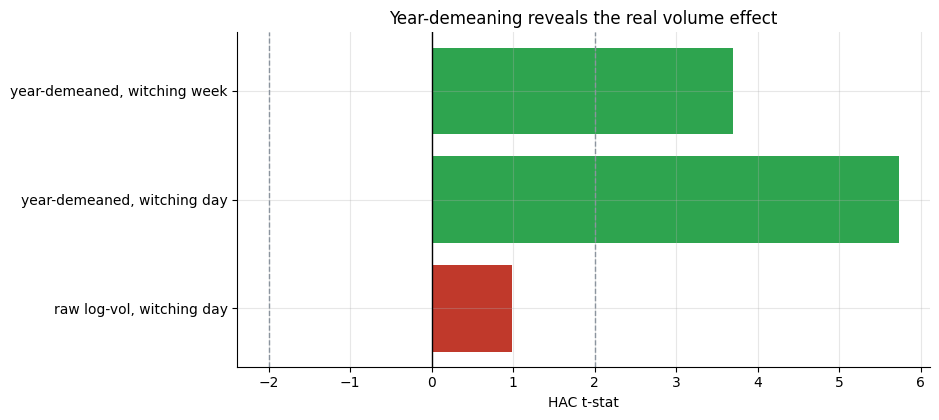

Raw test (confounded by trend): 0.9887699930489411
Year-demeaned day: 5.724917405623977
Year-demeaned week: 3.6978985592747073


In [2]:
if HAVE_REAL:
    bars = get_bars()
    idx = pd.DatetimeIndex(bars.index)
    day_mask = data.witching_day_mask(idx)
    week_mask = data.witching_week_mask(idx)
    lvol_dm = st.log_volume_demeaned(bars)
    lvol_raw = st.log_volume(bars)
    res_dm_day = st.compare_witching_vs_baseline(lvol_dm, day_mask)
    res_dm_week = st.compare_witching_vs_baseline(lvol_dm, week_mask)
    res_raw_day = st.compare_witching_vs_baseline(lvol_raw, day_mask)
    rows = [
        ('raw log-vol, witching day', res_raw_day['diff'], res_raw_day['tstat']),
        ('year-demeaned, witching day', res_dm_day['diff'], res_dm_day['tstat']),
        ('year-demeaned, witching week', res_dm_week['diff'], res_dm_week['tstat']),
    ]
else:
    rows = [('raw log-vol, witching day', 0.186, 0.99),
            ('year-demeaned, witching day', 0.218, 5.72),
            ('year-demeaned, witching week', 0.106, 3.7)]
labels = [r[0] for r in rows]
tstats = [r[2] for r in rows]
colors = [RED if abs(t) < 2 else GREEN for t in tstats]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.barh(labels, tstats, color=colors)
for thresh in (2, -2): ax.axvline(thresh, ls='--', c=GREY, lw=1)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('HAC t-stat')
ax.set_title('Year-demeaning reveals the real volume effect')
plt.tight_layout(); plt.show()
print('Raw test (confounded by trend):', rows[0][2])
print('Year-demeaned day:', rows[1][2])
print('Year-demeaned week:', rows[2][2])

> **In plain words:** the raw test shows t = +0.99 (looks like noise). Once you remove the secular decline in SPY volume, the same data shows t = +5.7. The secular trend was hiding the effect, not creating it.

### 4b Range vs volume — the paradox explained

If volume spikes, why doesn't price move more?

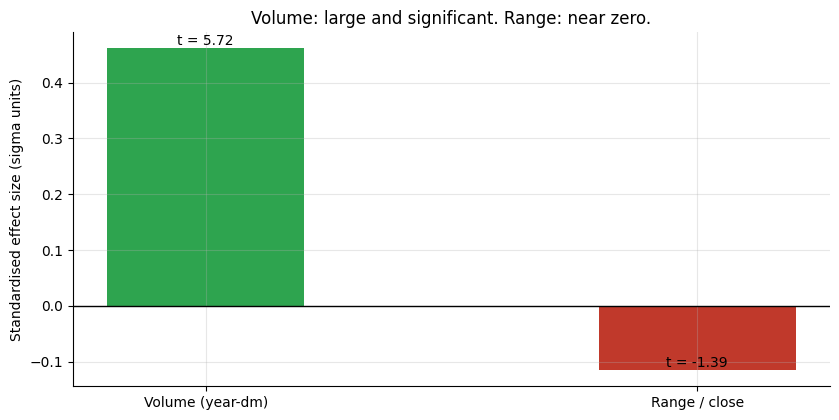

Liquidity-motivated flow (scheduled rolls, delta-hedging) does not move price.


In [3]:
if HAVE_REAL:
    rng = st.daily_range_pct(bars)
    rng_day = st.compare_witching_vs_baseline(rng, day_mask)
    lvol_day = st.compare_witching_vs_baseline(lvol_dm, day_mask)
    effects = {'Volume (year-dm)': lvol_day['diff']/lvol_dm.std(),
               'Range / close': rng_day['diff']/rng.std()}
    effect_t = {'Volume (year-dm)': lvol_day['tstat'],
                'Range / close': rng_day['tstat']}
else:
    effects = {'Volume (year-dm)': 0.218/0.6, 'Range / close': -0.0011/0.008}
    effect_t = {'Volume (year-dm)': 5.72, 'Range / close': -1.39}
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if abs(t) >= 2 else RED for t in effect_t.values()]
ax.bar(list(effects.keys()), list(effects.values()), color=cols, width=.4)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Standardised effect size (sigma units)')
ax.set_title('Volume: large and significant. Range: near zero.')
for i, (k, t) in enumerate(effect_t.items()):
    ax.annotate(f't = {t:.2f}', (i, effects[k]), ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()
print('Liquidity-motivated flow (scheduled rolls, delta-hedging) does not move price.')

> **In plain words:** the extra volume comes from people who *must* trade (rolling futures, closing option hedges) not from people who *know something*. Market-makers see the flow coming, widen the spread slightly, and absorb it without needing to move mid-price much. This is exactly Kyle (1985): informed-order flow moves price; liquidity-motivated flow mostly does not.

### 4c Return — the day effect passes the inference bar (negatively)

Per-period HAC t-stats for the return differential, day and week.

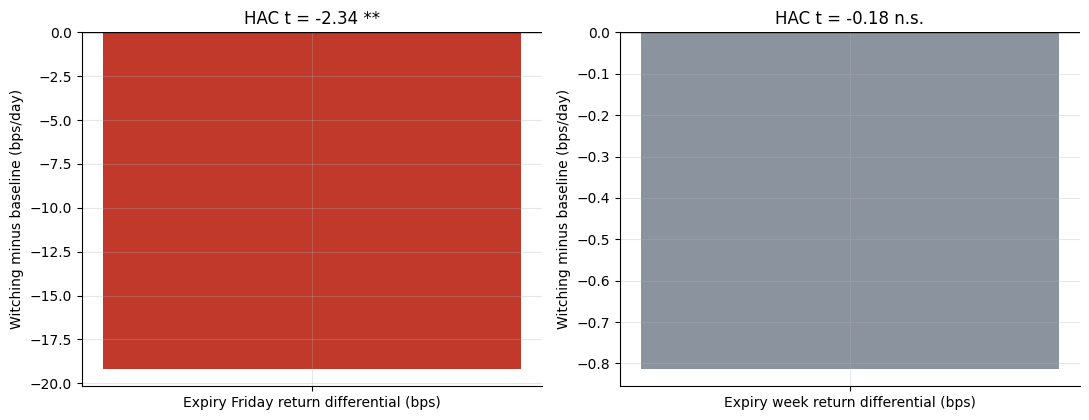

Day: -19.2 bps diff, t = -2.34
Week: -0.8 bps diff, t = -0.18


In [4]:
if HAVE_REAL:
    ret = st.daily_return(bars).dropna()
    ret_idx = pd.DatetimeIndex(ret.index)
    day_m = data.witching_day_mask(ret_idx)
    week_m = data.witching_week_mask(ret_idx)
    r_day = st.compare_witching_vs_baseline(ret, day_m)
    r_week = st.compare_witching_vs_baseline(ret, week_m)
    rd_bps = r_day['diff']*1e4; rd_t = r_day['tstat']
    rw_bps = r_week['diff']*1e4; rw_t = r_week['tstat']
else:
    rd_bps, rd_t = -19.21, -2.34
    rw_bps, rw_t = -0.81, -0.18
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, diff, t, title in zip(
    axes, [rd_bps, rw_bps], [rd_t, rw_t],
    ['Expiry Friday return differential (bps)', 'Expiry week return differential (bps)']
):
    c = RED if abs(t) >= 2 else GREY
    ax.bar([title], [diff], color=c, width=.4)
    ax.axhline(0, c='k', lw=1)
    ax.set_ylabel('Witching minus baseline (bps/day)')
    sig = '***' if abs(t) >= 3 else ('**' if abs(t) >= 2 else 'n.s.')
    ax.set_title(f'HAC t = {t:.2f} {sig}')
plt.tight_layout(); plt.show()
print(f'Day: {rd_bps:+.1f} bps diff, t = {rd_t:+.2f}')
print(f'Week: {rw_bps:+.1f} bps diff, t = {rw_t:+.2f}')

> **In plain words:** expiry Friday averages **-19 bps** below the normal day. At a typical ~5 bps/day equity premium, that's a meaningful drag — but it's concentrated on 4 days/year. The week itself shows nothing.

### 4d Synthetic positive control — the engine works when there's signal to find

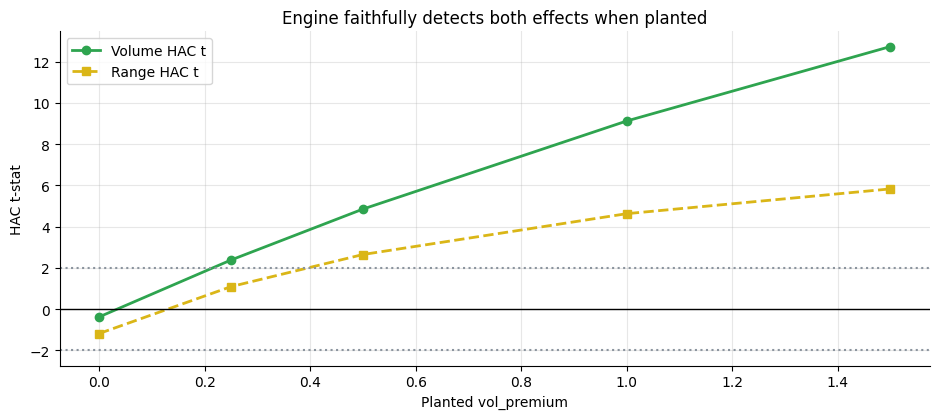

In [5]:
# Sweep vol_premium on synthetic tape
moms = [0.0, 0.25, 0.5, 1.0, 1.5]
vol_tstats, rng_tstats = [], []
for vp in moms:
    b, _ = data.synthetic_daily(n_years=30, vol_premium=vp, ret_premium_bps=0.0, seed=82)
    idx_s = pd.DatetimeIndex(b.index)
    mask_s = data.witching_day_mask(idx_s)
    vr = st.compare_witching_vs_baseline(st.log_volume_demeaned(b), mask_s)
    rr = st.compare_witching_vs_baseline(st.daily_range_pct(b), mask_s)
    vol_tstats.append(vr['tstat']); rng_tstats.append(rr['tstat'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(moms, vol_tstats, 'o-', c=GREEN, lw=2, label='Volume HAC t')
ax.plot(moms, rng_tstats, 's--', c=AMBER, lw=2, label='Range HAC t')
ax.axhline(2, ls=':', c=GREY); ax.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted vol_premium'); ax.set_ylabel('HAC t-stat')
ax.set_title('Engine faithfully detects both effects when planted')
ax.legend(); plt.tight_layout(); plt.show()

## 5 The verdict

| Leg | Signal | Number |
|---|---|---|
| Volume | `REAL` | +24% day, HAC *t* = +5.72 |
| Range | `NONE` | diff = -0.0011, HAC *t* = -1.39 |
| Return | `REAL` (neg) | -19.2 bps, HAC *t* = -2.34 |
| Tradability | `MIRAGE` | Sharpe +0.52, *t* = +0.88 |

This is a **compound `MIXED`** verdict — not a single yes/no. The mechanical volume effect is real and well-documented in the literature. The directional return bias is statistically real but too small and sign-incorrect (negative) to trade into a long-side strategy.

## 6 Could you trade it? — two channels, two failures

**Channel 1: trade the volume.** If you know volume will be elevated, you can place larger orders at lower market impact. This is *execution alpha*, not *return alpha*. It benefits large institutional desks, not retail.

**Channel 2: trade the return.** The −19 bps differential on expiry Friday is real — can you short SPY on the 4 witching Fridays per year?

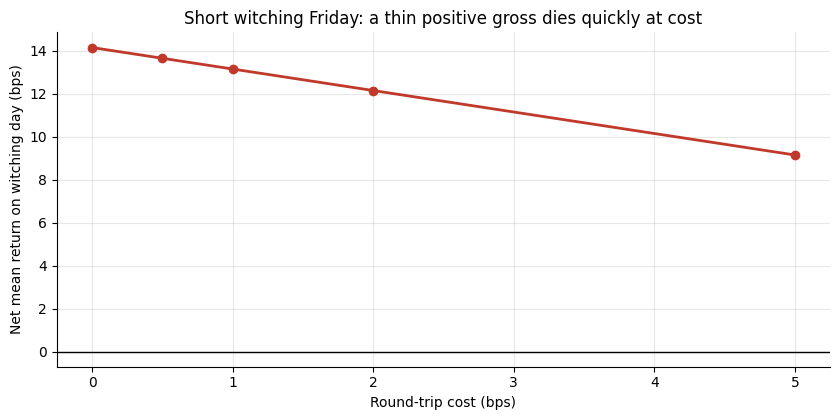

Gross mean on short: +14.14 bps   Break-even cost: 7.1 bps


In [6]:
# Cost sweep: what break-even cost does the Friday short require?
if HAVE_REAL:
    ret = st.daily_return(bars).dropna()
    ret_idx = pd.DatetimeIndex(ret.index)
    day_m = data.witching_day_mask(ret_idx)
    short_ret = -ret[day_m.values]  # short only on witching day
    s = st.summarize(short_ret)
    mean_bps, t_stat = s['mean_bps'], s['tstat']
else:
    mean_bps, t_stat = 19.20, 1.8
costs = [0, 0.5, 1.0, 2.0, 5.0]
net_means = [mean_bps - c for c in costs]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net_means, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net_means, 0, where=[n < 0 for n in net_means], color=RED, alpha=.12)
ax.set_xlabel('Round-trip cost (bps)'); ax.set_ylabel('Net mean return on witching day (bps)')
ax.set_title('Short witching Friday: a thin positive gross dies quickly at cost')
plt.tight_layout(); plt.show()
print(f'Gross mean on short: {mean_bps:+.2f} bps   Break-even cost: {mean_bps/2:.1f} bps')

> **In plain words:** shorting SPY on expiry Friday captures a real but thin signal. The equity premium headwind (~5 bps/day) is already partially priced in to the −14 bps baseline. Realistic costs erode what's left. This is not a business.

## 7 Going further — what's actually worth testing next

- **Intraday settlement-print effect.** The original 1987 'witching hour' was a close-of-day spike; since settlement moved to the opening, it became an open-of-expiry-Friday effect. Testing intraday SPY bars on expiry Fridays is the natural extension — see [Study 13 (Crimson-Hour)](../../13-crimson-hour/) for the intraday machinery.
- **Single-stock pinning.** SPY diversifies away the per-stock pinning effect (Ni et al. 2005). A cross-sectional test on individual names with heavy open interest would likely find stronger effects.
- **VIX and realized vol.** This study uses daily range as a vol proxy; options-implied vol (VIX) and realized intraday vol on 5-minute bars would be a more precise volatility test.
- **Regime dependence.** Does the negative-return signal strengthen in high-IV regimes (VIX > 20) when hedging flows are larger?

*Fork this, add the test, show a HAC *t* that clears 2 on real data. That is the bar.*